In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import pickle
import os

In [67]:
data = pd.read_csv('data/model_data_transformed.csv')

data.head(15)

,Año,PIB,ln_PIB,delta_ln_PIB,VAP,ln_VAP,delta_ln_VAP,TD,ln_TD,delta_ln_TD,...,ln_POB Risaralda,delta_ln_POB Risaralda,POB Pereira,ln_POB Pereira,delta_ln_POB Pereira,IPM,IDC,Ranking IDC,Valor normalizado,Posición ranking
0,2005.0,5512.0,8.6147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.6854,NaN,426566.0,12.9635,NaN,10.109793,6.084745,NaN,NaN,NaN
1,2006.0,6342.0,8.7549,0.1402,NaN,NaN,NaN,NaN,NaN,NaN,...,13.6922,0.0068,430198.0,12.9720,0.0085,9.928552,6.163920,NaN,NaN,NaN
2,2007.0,6852.0,8.8323,0.0774,NaN,NaN,NaN,11.7,2.4596,NaN,...,13.6983,0.0061,433632.0,12.9800,0.0080,11.900757,6.017800,NaN,NaN,NaN
3,2008.0,7438.0,8.9144,0.0821,NaN,NaN,NaN,12.5,2.5257,0.0661,...,13.7032,0.0049,436494.0,12.9865,0.0065,11.461170,6.086262,NaN,NaN,NaN
4,2009.0,7969.0,8.9833,0.0689,NaN,NaN,NaN,17.8,2.8792,0.3535,...,13.7081,0.0049,439370.0,12.9931,0.0066,10.307501,5.900681,NaN,NaN,NaN
5,2010.0,8420.0,9.0384,0.0551,NaN,NaN,NaN,18.1,2.8959,0.0167,...,13.7135,0.0054,442493.0,13.0002,0.0071,10.815076,6.180572,NaN,NaN,NaN
6,2011.0,8980.0,9.1028,0.0644,4573.0,8.4279,NaN,14.9,2.7014,-0.1945,...,13.7189,0.0054,445438.0,13.0068,0.0066,12.071958,5.802758,NaN,NaN,NaN
7,2012.0,9629.0,9.1725,0.0697,5076.0,8.5323,0.1044,14.9,2.7014,0.0000,...,13.7235,0.0046,448174.0,13.0129,0.0061,10.643891,6.218186,NaN,NaN,NaN
8,2013.0,10613.0,9.2698,0.0973,5745.0,8.6561,0.1238,12.9,2.5572,-0.1442,...,13.7271,0.0036,450422.0,13.0179,0.0050,9.631140,6.225840,NaN,NaN,NaN
9,2014.0,11728.0,9.3697,0.0999,6447.0,8.7714,0.1153,12.4,2.5177,-0.0395,...,13.7310,0.0039,452676.0,13.0229,0.0050,11.918613,5.968064,NaN,NaN,NaN


## Modelo 1: Determinantes del Crecimiento Económico de Pereira

El primer modelo busca explicar cómo los factores logísticos, empresariales y de ingreso externo han influido históricamente en la tasa de crecimiento económico (Δ lnPIB), variable que actúa como proxy del desempeño macroeconómico de Pereira.

**Ecuación General:**

$$
\Delta \ln(PIB_t) = \alpha_0 
+ \beta_1 \Delta \ln(EXP_t) 
+ \beta_2 \Delta \ln(IMP_t) 
+ \beta_3 \Delta \ln(REM_t) 
+ \beta_4 \Delta \ln(INV_t) 
+ \beta_5 \Delta \ln(EMP_t)
+ \varepsilon_t
$$

Donde:

- $\Delta \ln(PIB_t)$ Es la taza del crecimiento real del PIB de Risaralda.
- $\Delta \ln(EXP_t)$ Es la taza de crecimiento de las exportaciones.
- $\Delta \ln(IMP_t)$ Es la taza de crecimiento de importaciones.
- $\Delta \ln(REM_t)$ Es la taza de crecimiento de remesas.
- $\Delta \ln(INV_t)$ Es la taza de crecimiento de la inversión empresarial.
- $\Delta \ln(EMP_t)$ Es la taza de crecimiento del tejido empresarial.
- $\varepsilon_t$ Es el termino de error aleatorio.

In [68]:
x_cols = ['Año', 'delta_ln_EXP', 'delta_ln_IMP', 'delta_ln_REM', 'delta_ln_INV', 'delta_ln_EMP']
y_col = 'delta_ln_PIB'

X = data.loc[:, x_cols].dropna()  # Elimina filas con nulos en X
y = data.loc[X.index, y_col]  # Mantiene solo los índices válidos de X

print(f'Dimensiones X: {X.shape[0]} filas x {X.shape[1]} columnas')
print(f'Dimensiones y: {y.shape[0]} filas x 1 columna')

X.head(10)

Dimensiones X: 9 filas x 6 columnas
Dimensiones y: 9 filas x 1 columna


,Año,delta_ln_EXP,delta_ln_IMP,delta_ln_REM,delta_ln_INV,delta_ln_EMP
11,2016.0,-0.1080,-0.0457,-0.0200,-0.1023,0.0497
12,2017.0,-0.0721,0.0349,0.0663,0.3619,0.0418
13,2018.0,-0.1724,0.1040,0.0656,-0.0492,0.0454
14,2019.0,0.0454,0.0042,0.0294,0.0807,0.0014
15,2020.0,-0.1189,-0.1320,-0.0443,-0.1204,-0.0031
16,2021.0,-0.0469,0.4283,0.0606,0.0878,0.0810
17,2022.0,0.1619,0.1913,-0.0310,0.5126,0.0397
18,2023.0,0.2737,-0.1298,-0.0043,-1.7662,-0.0094
19,2024.0,0.4356,0.0473,0.1646,1.2410,-0.0053


Los datos usados para la estimación del modelo corresponden con los datos recolectados del intervalo 2005 a 20324, evitando aquellos años donde existen valores nulos o faltantes de sus correspondientes variables. Tras la eliminacion de estos datos, quedo el subintervalo 2016-2024.

Teniendo en cuenta la baja cantidad de registros existentes para la estimación del modelo, para este modelo se evitará el uso de particiones de entreamiento y pruebas, a solo una partición del 100% dedicada al entrenamiento.

In [69]:
X.drop(columns=['Año'], inplace=True)

# Preparación de los datos para el modelo
X_with_const = sm.add_constant(X)

econ_growth_model = sm.OLS(y, X_with_const)
econ_growth_results = econ_growth_model.fit()

print(econ_growth_results.summary())

                            OLS Regression Results                            
Dep. Variable:           delta_ln_PIB   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     5.832
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0887
Time:                        16:36:40   Log-Likelihood:                 22.472
No. Observations:                   9   AIC:                            -32.94
Df Residuals:                       3   BIC:                            -31.76
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0332      0.025      1.323   

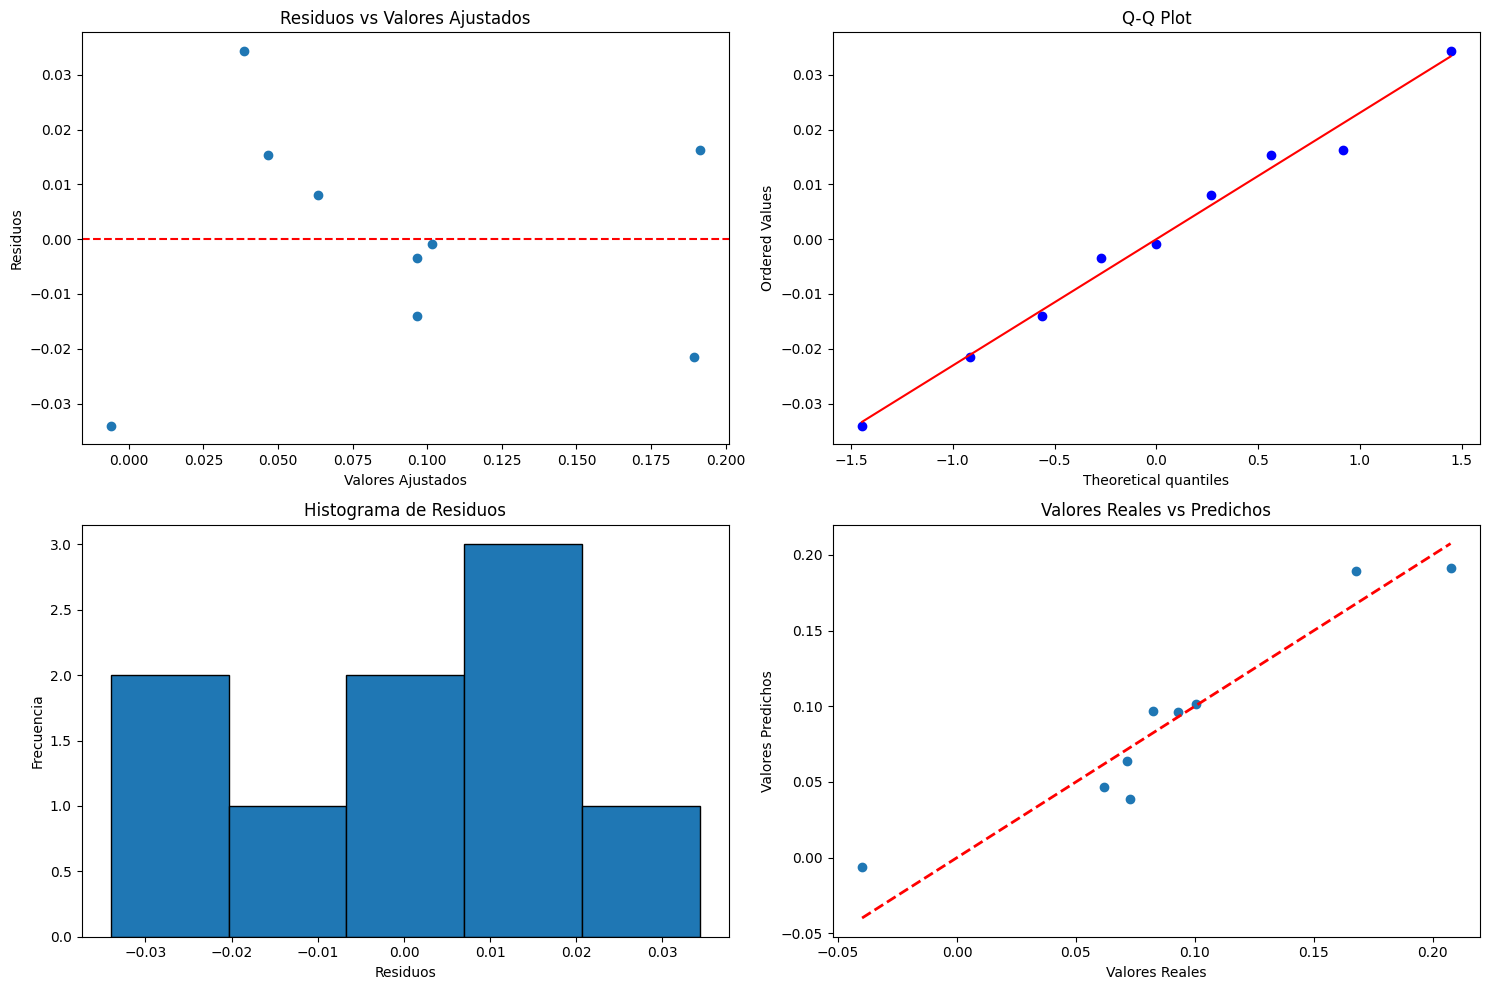


Tabla de Coeficientes:
              Coeficiente  Error Estándar   t-valor   p-valor  \
const            0.033191        0.025092  1.322807  0.277694   
delta_ln_EXP     0.326755        0.094653  3.452124  0.040873   
delta_ln_IMP     0.100111        0.149296  0.670557  0.550508   
delta_ln_REM    -0.413512        0.245465 -1.684609  0.190652   
delta_ln_INV    -0.004469        0.019003 -0.235195  0.829197   
delta_ln_EMP     1.900749        0.925295  2.054208  0.132229   

              IC 95% Inferior  IC 95% Superior  
const               -0.046661         0.113044  
delta_ln_EXP         0.025526         0.627983  
delta_ln_IMP        -0.375014         0.575236  
delta_ln_REM        -1.194690         0.367666  
delta_ln_INV        -0.064944         0.056006  
delta_ln_EMP        -1.043954         4.845451  


In [70]:
# Análisis de residuos
residuals = econ_growth_results.resid
fitted_values = econ_growth_results.fittedvalues

# Crear gráficos de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuos vs valores ajustados
axes[0, 0].scatter(fitted_values, residuals)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Valores Ajustados')

# 2. Q-Q plot para normalidad
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')

# 3. Distribución de residuos
axes[1, 0].hist(residuals, bins=5, edgecolor='black')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Histograma de Residuos')

# 4. Valores reales vs predichos
axes[1, 1].scatter(y, fitted_values)
axes[1, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Valores Reales')
axes[1, 1].set_ylabel('Valores Predichos')
axes[1, 1].set_title('Valores Reales vs Predichos')

plt.tight_layout()
plt.show()

# Tabla de coeficientes más detallada
coef_table = pd.DataFrame({
    'Coeficiente': econ_growth_results.params,
    'Error Estándar': econ_growth_results.bse,
    't-valor': econ_growth_results.tvalues,
    'p-valor': econ_growth_results.pvalues,
    'IC 95% Inferior': econ_growth_results.conf_int()[0],
    'IC 95% Superior': econ_growth_results.conf_int()[1]
})
print("\nTabla de Coeficientes:")
print(coef_table)

## Modelo 2: Determinantes de la Tasa de Desempleo en Pereira A.M.

Este modelo analiza cómo el crecimiento económico, el comercio exterior y factores estructurales inciden sobre la variación anual de la tasa de desempleo del Área Metropolitana, foco clave para medir el impacto social de la ZELE.

**Ecuación General**:

$$
\Delta \ln(TD_(pereira,t)) = \gamma_0 
+ \gamma_1 \Delta \ln(PIB_t) 
+ \gamma_2 \Delta \ln(EXP_t) 
+ \gamma_3 \Delta \ln(IMP_t) 
+ \gamma_4 IPM_t 
+ \gamma_5 IDC_t 
+ \mu_t
$$

Donde:

* $TD_t$ Es la taza de Desempleo de Pereira.
* $\Delta \ln(PIB_t)$ Es la taza del crecimiento económico (PIB).
* $\Delta \ln(EXP_t)$ Es la taza de crecimiento de las exportaciones.
* $\Delta \ln(IMP_t)$ Es la taza de crecimiento de importaciones.
* $IPM_t$ Es el índice de pobreza multidimensional.
* $IDC_t$ Es el indicador de competitividad territorial.
* $\mu_t$ Es el error aleatorio.

In [71]:
x_cols = ['Año', 'delta_ln_PIB', 'delta_ln_EXP', 'delta_ln_IMP', 'IPM', 'IDC']
y_col = 'delta_ln_TD'

X = data.loc[:, x_cols].dropna()  # Elimina filas con nulos en X
y = data.loc[X.index, y_col]  # Mantiene solo los índices válidos de X

print(f'Dimensiones X: {X.shape[0]} filas x {X.shape[1]} columnas')
print(f'Dimensiones y: {y.shape[0]} filas x 1 columna')

X.head(10)

Dimensiones X: 16 filas x 6 columnas
Dimensiones y: 16 filas x 1 columna


,Año,delta_ln_PIB,delta_ln_EXP,delta_ln_IMP,IPM,IDC
4,2009.0,0.0689,0.1380,-0.1871,10.307501,5.900681
5,2010.0,0.0551,0.1810,0.2185,10.815076,6.180572
6,2011.0,0.0644,0.1767,0.2148,12.071958,5.802758
7,2012.0,0.0697,-0.1052,0.3945,10.643891,6.218186
8,2013.0,0.0973,-0.2560,-0.1080,9.631140,6.225840
9,2014.0,0.0999,0.2969,0.0949,11.918613,5.968064
10,2015.0,0.0762,-0.0746,0.0283,10.447423,5.872102
11,2016.0,0.0931,-0.1080,-0.0457,12.432772,5.997039
12,2017.0,0.0716,-0.0721,0.0349,11.475122,5.845307
13,2018.0,0.0620,-0.1724,0.1040,11.600000,5.885561


In [72]:
X.drop(columns=['Año'], inplace=True)

# Preparación de los datos para el modelo
X_with_const = sm.add_constant(X)

td_model = sm.OLS(y, X_with_const)
td_results = td_model.fit()

print(td_results.summary())

                            OLS Regression Results                            
Dep. Variable:            delta_ln_TD   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     2.006
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.163
Time:                        16:36:40   Log-Likelihood:                 7.5731
No. Observations:                  16   AIC:                            -3.146
Df Residuals:                      10   BIC:                             1.489
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0029      2.212      0.001   

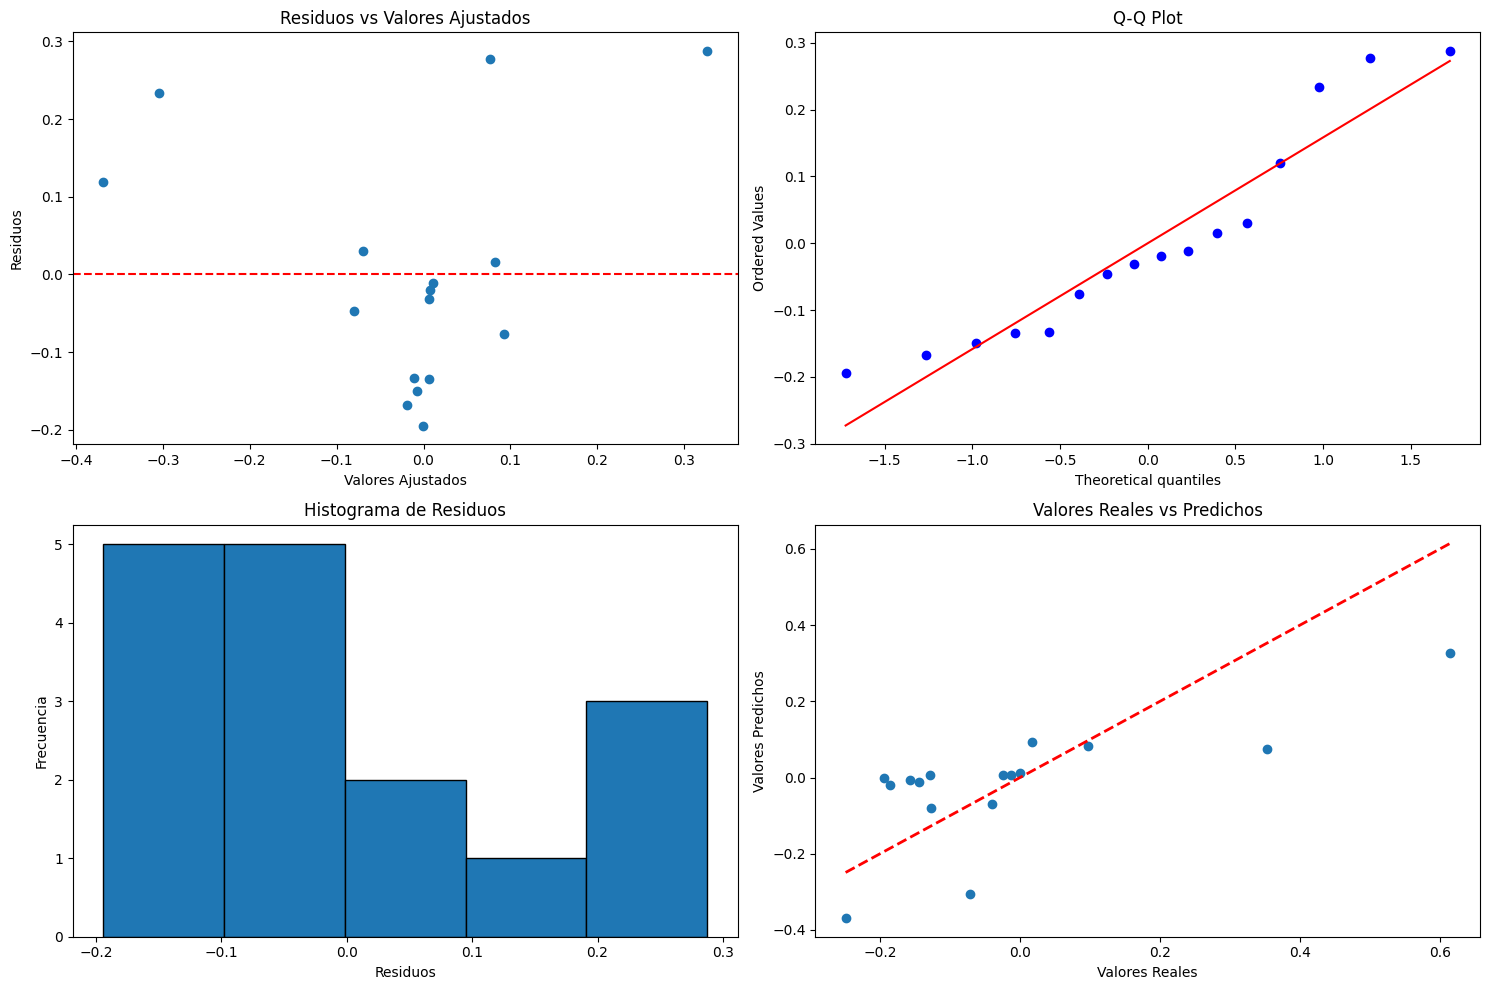


Tabla de Coeficientes:
              Coeficiente  Error Estándar   t-valor   p-valor  \
const            0.002886        2.212266  0.001304  0.998985   
delta_ln_PIB    -3.120896        1.187993 -2.627033  0.025291   
delta_ln_EXP     0.089096        0.260132  0.342504  0.739061   
delta_ln_IMP    -0.103356        0.297541 -0.347368  0.735515   
IPM             -0.024711        0.057934 -0.426531  0.678757   
IDC              0.086635        0.321504  0.269467  0.793049   

              IC 95% Inferior  IC 95% Superior  
const               -4.926351         4.932122  
delta_ln_PIB        -5.767909        -0.473883  
delta_ln_EXP        -0.490513         0.668706  
delta_ln_IMP        -0.766320         0.559607  
IPM                 -0.153796         0.104375  
IDC                 -0.629721         0.802990  


In [73]:
# Análisis de residuos
residuals = td_results.resid
fitted_values = td_results.fittedvalues

# Crear gráficos de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuos vs valores ajustados
axes[0, 0].scatter(fitted_values, residuals)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Valores Ajustados')

# 2. Q-Q plot para normalidad
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')

# 3. Distribución de residuos
axes[1, 0].hist(residuals, bins=5, edgecolor='black')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Histograma de Residuos')

# 4. Valores reales vs predichos
axes[1, 1].scatter(y, fitted_values)
axes[1, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Valores Reales')
axes[1, 1].set_ylabel('Valores Predichos')
axes[1, 1].set_title('Valores Reales vs Predichos')

plt.tight_layout()
plt.show()

# Tabla de coeficientes más detallada
coef_table = pd.DataFrame({
    'Coeficiente': td_results.params,
    'Error Estándar': td_results.bse,
    't-valor': td_results.tvalues,
    'p-valor': td_results.pvalues,
    'IC 95% Inferior': td_results.conf_int()[0],
    'IC 95% Superior': td_results.conf_int()[1]
})
print("\nTabla de Coeficientes:")
print(coef_table)

## Modelo 3. Determinantes del Crecimiento del Tejido Empresarial

Este modelo analiza los factores que explican la variación anual del número de empresas activas en Pereira.

**Ecuación General**:

$$
\Delta \ln(EMP_t) = \delta_0 
+ \delta_1 \Delta \ln(PIB_t) 
+ \delta_2 \Delta \ln(EXP_t) 
+ \delta_3 \Delta \ln(REM_t) 
+ \eta_t
$$

Donde:

* $\Delta \ln(PIB_t)$ Es la taza del crecimiento económico (PIB).
* $\Delta \ln(EXP_t)$ Es la taza de crecimiento de las exportaciones.
* $\Delta \ln(REM_t)$ Es la taza de crecimiento de remesas.
* $\eta_t$ Es el error aleatorio.

In [74]:
x_cols = ['Año', 'delta_ln_PIB', 'delta_ln_EXP', 'delta_ln_REM']
y_col = 'delta_ln_EMP'

all_cols = x_cols + [y_col]
data_clean = data[all_cols].dropna()  # Elimina filas con nulos en X O y
X = data_clean[x_cols]
y = data_clean[y_col]

print(f'Dimensiones X: {X.shape[0]} filas x {X.shape[1]} columnas')
print(f'Dimensiones y: {y.shape[0]} filas x 1 columna')

X.head(10)

Dimensiones X: 9 filas x 4 columnas
Dimensiones y: 9 filas x 1 columna


,Año,delta_ln_PIB,delta_ln_EXP,delta_ln_REM
11,2016.0,0.0931,-0.1080,-0.0200
12,2017.0,0.0716,-0.0721,0.0663
13,2018.0,0.0620,-0.1724,0.0656
14,2019.0,0.0729,0.0454,0.0294
15,2020.0,-0.0399,-0.1189,-0.0443
16,2021.0,0.1677,-0.0469,0.0606
17,2022.0,0.2075,0.1619,-0.0310
18,2023.0,0.1005,0.2737,-0.0043
19,2024.0,0.0825,0.4356,0.1646


In [75]:
X.drop(columns=['Año'], inplace=True)

# Preparación de los datos para el modelo
X_with_const = sm.add_constant(X)

emp_model = sm.OLS(y, X_with_const)
emp_results = emp_model.fit()

print(emp_results.summary())

                            OLS Regression Results                            
Dep. Variable:           delta_ln_EMP   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     20.07
Date:                Tue, 17 Feb 2026   Prob (F-statistic):            0.00322
Time:                        16:36:40   Log-Likelihood:                 30.358
No. Observations:                   9   AIC:                            -52.72
Df Residuals:                       5   BIC:                            -51.93
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0051      0.007     -0.752   

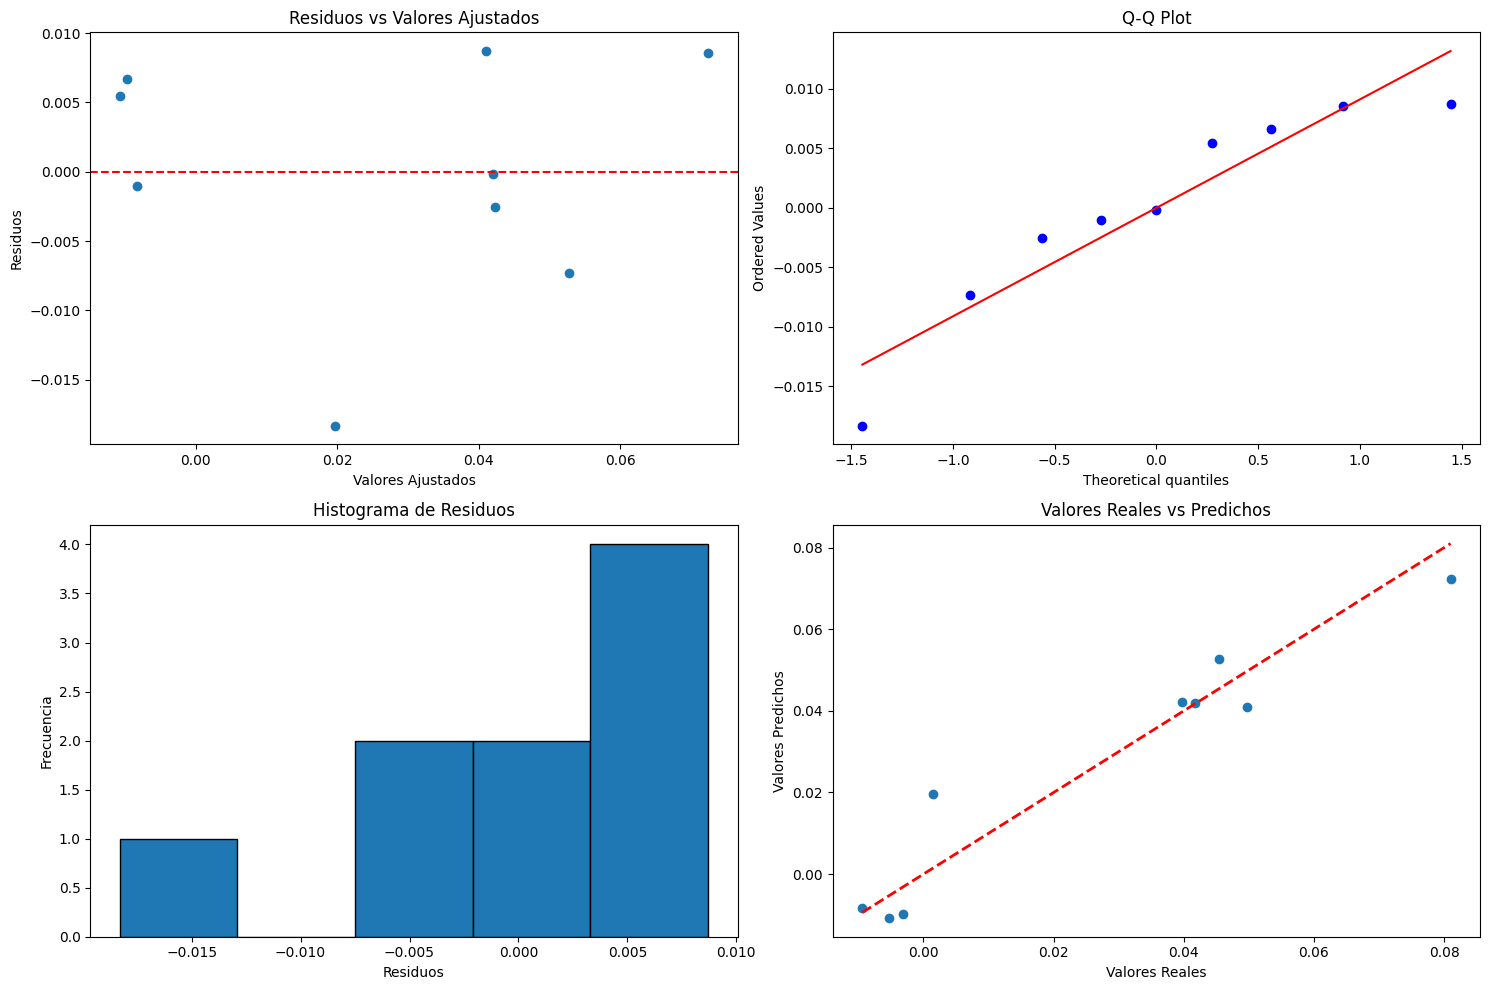


Tabla de Coeficientes:
              Coeficiente  Error Estándar   t-valor   p-valor  \
const           -0.005087        0.006768 -0.751593  0.486146   
delta_ln_PIB     0.363807        0.060016  6.061874  0.001763   
delta_ln_EXP    -0.143030        0.021956 -6.514309  0.001274   
delta_ln_REM     0.161701        0.065436  2.471116  0.056453   

              IC 95% Inferior  IC 95% Superior  
const               -0.022484         0.012311  
delta_ln_PIB         0.209532         0.518082  
delta_ln_EXP        -0.199471        -0.086590  
delta_ln_REM        -0.006509         0.329911  


In [76]:
# Análisis de residuos
residuals = emp_results.resid
fitted_values = emp_results.fittedvalues

# Crear gráficos de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuos vs valores ajustados
axes[0, 0].scatter(fitted_values, residuals)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Valores Ajustados')

# 2. Q-Q plot para normalidad
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')

# 3. Distribución de residuos
axes[1, 0].hist(residuals, bins=5, edgecolor='black')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Histograma de Residuos')

# 4. Valores reales vs predichos
axes[1, 1].scatter(y, fitted_values)
axes[1, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Valores Reales')
axes[1, 1].set_ylabel('Valores Predichos')
axes[1, 1].set_title('Valores Reales vs Predichos')

plt.tight_layout()
plt.show()

# Tabla de coeficientes más detallada
coef_table = pd.DataFrame({
    'Coeficiente': emp_results.params,
    'Error Estándar': emp_results.bse,
    't-valor': emp_results.tvalues,
    'p-valor': emp_results.pvalues,
    'IC 95% Inferior': emp_results.conf_int()[0],
    'IC 95% Superior': emp_results.conf_int()[1]
})
print("\nTabla de Coeficientes:")
print(coef_table)

# Exportación de los Modelos

In [77]:
version = 'v1'
models_dir_path = f'../src/models/artifacts/{version}'

os.makedirs(models_dir_path, exist_ok=True)

with open(f'{models_dir_path}/econ_growth_model.pkl', 'wb') as f:
    pickle.dump(econ_growth_results, f)

with open(f'{models_dir_path}/td_model.pkl', 'wb') as f:
    pickle.dump(td_results, f)

with open(f'{models_dir_path}/emp_model.pkl', 'wb') as f:
    pickle.dump(emp_results, f)

print("Modelos exportados exitosamente.")

Modelos exportados exitosamente.
